## 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib

import shap

C:\Users\jonty\miniconda3\envs\ml_app2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2: Load Dataset

In [2]:
# Load CSV file
df = pd.read_csv("data/train.csv")

# Display first 5 rows
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


### 4: Convert Target Variable

In [3]:
df["Attrition"] = df["Attrition"].map({
    "Stayed": 0,
    "Left": 1
})
df["Attrition"]

0        0
1        0
2        0
3        0
4        0
        ..
59593    1
59594    1
59595    0
59596    1
59597    0
Name: Attrition, Length: 59598, dtype: int64

### 3: Separate Features and Target

In [4]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [5]:
X

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Marital Status,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,Married,0,Mid,Medium,89,No,No,No,Excellent,Medium
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,Divorced,3,Mid,Medium,21,No,No,No,Fair,Low
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,Married,3,Mid,Medium,74,No,No,No,Poor,Low
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,Single,2,Mid,Small,50,Yes,No,No,Good,Medium
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,Divorced,0,Senior,Medium,68,No,No,No,Fair,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59593,37195,50,Female,12,Education,4414,Fair,High,Average,1,...,Single,2,Senior,Small,35,No,No,Yes,Poor,Very High
59594,6266,18,Male,4,Healthcare,8040,Fair,High,High,3,...,Single,0,Senior,Medium,73,No,No,No,Fair,Medium
59595,54887,22,Female,14,Technology,7944,Fair,High,High,0,...,Married,2,Entry,Small,29,No,Yes,No,Good,Medium
59596,861,23,Male,8,Education,2931,Fair,Very High,Average,0,...,Single,0,Entry,Large,9,No,No,No,Good,Low


In [6]:
y

0        0
1        0
2        0
3        0
4        0
        ..
59593    1
59594    1
59595    0
59596    1
59597    0
Name: Attrition, Length: 59598, dtype: int64

### Drop Employee ID

In [7]:
employee_ids = X["Employee ID"]
X = X.drop("Employee ID", axis=1)

### 5: Identify Categorical Columns

In [8]:
cat_features = X.select_dtypes(include=["object","string"]).columns.tolist()
print(cat_features)

['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']


### 6: Train Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### 7: Train CatBoost Model and Make Prediction

In [10]:
# model = CatBoostClassifier(
#     iterations=500,
#     learning_rate=0.05,
#     depth=6,
#     loss_function='Logloss',
#     eval_metric='Accuracy',
#     random_seed=42,
#     verbose=100
# )

In [11]:
model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    eval_metric='Accuracy',
    verbose=100,
    random_state=42
)

In [12]:
model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

0:	learn: 0.7209824	total: 420ms	remaining: 3m 29s
100:	learn: 0.7624061	total: 24.4s	remaining: 1m 36s
200:	learn: 0.7653215	total: 50.8s	remaining: 1m 15s
300:	learn: 0.7694954	total: 1m 18s	remaining: 51.9s
400:	learn: 0.7738370	total: 1m 46s	remaining: 26.3s
499:	learn: 0.7767104	total: 2m 14s	remaining: 0us


In [13]:
y_pred = model.predict(X_test)

In [14]:
y_pred

array([0, 0, 0, ..., 1, 1, 0], dtype=int64)

### 8: Evaluate Model

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7540268456375839

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.76      0.77      6252
           1       0.74      0.74      0.74      5668

    accuracy                           0.75     11920
   macro avg       0.75      0.75      0.75     11920
weighted avg       0.75      0.75      0.75     11920



In [16]:
train_pred = model.predict(X_train)
train_acc = accuracy_score(y_train, train_pred)
print("Training Accuracy:", train_acc)

Training Accuracy: 0.7748856915139057


In [17]:
# Testing Accuracy is 75% and Training Accuracy: 77% therefore the model is generalizing well.

### 9: Feature Importance

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))

                 Feature  Importance
14             Job Level   20.386506
12        Marital Status   17.234930
17           Remote Work   14.297362
5      Work-Life Balance    9.990765
8   Number of Promotions    5.129878
10    Distance from Home    4.558206
11       Education Level    3.939495
20    Company Reputation    3.650352
13  Number of Dependents    3.582920
1                 Gender    3.059215


In [19]:
# 'Job Level' shows which features most influence attrition.

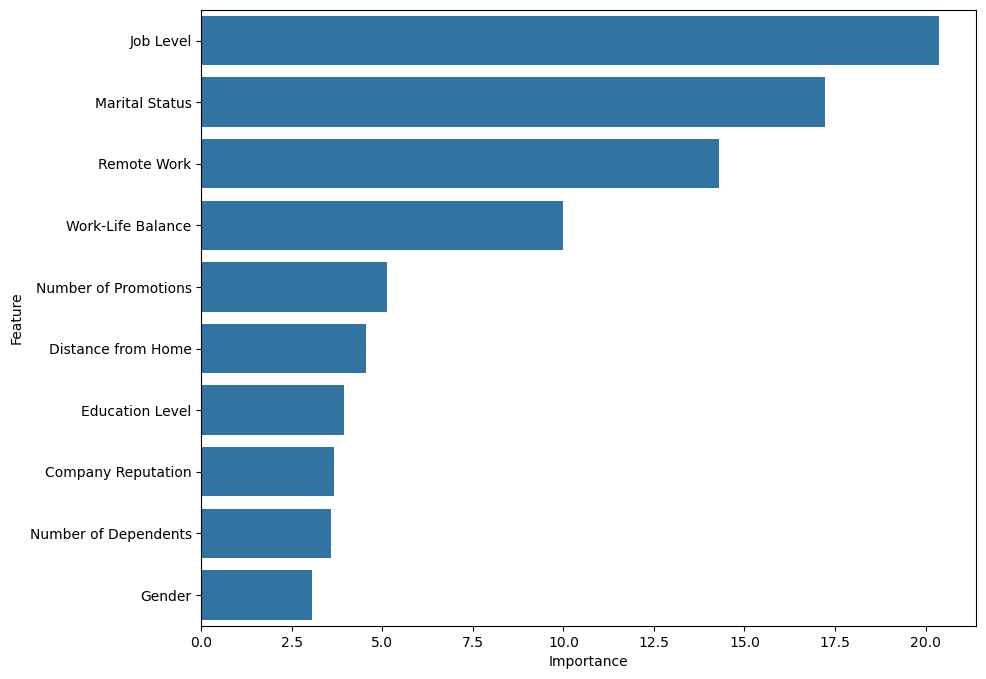

In [20]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.show()

### 10: Save Model

In [21]:
joblib.dump(model,"model/employee_attrition_catboost.pkl")

['model/employee_attrition_catboost.pkl']

### 11: Save Feature List

In [22]:
joblib.dump(list(X.columns),"model/feature_columns_catboost.pkl")

['encoder/feature_columns_catboost.pkl']

### 12: Save Categorical Columns

In [23]:
joblib.dump(cat_features,"model/categorical_columns_catboost.pkl")

['encoder/categorical_columns_catboost.pkl']

### 13: Load Saved Files Later

In [24]:
# model = joblib.load("model/employee_attrition_catboost.pkl")

# feature_columns = joblib.load("encoder/feature_columns_catboost.pkl")

# cat_features = joblib.load("encoder/categorical_columns_catboost.pkl")

### SHAP Explainability

In [25]:
explainer = shap.TreeExplainer(model)

### Generate SHAP Values

In [26]:
sample = X_test.iloc[:5]
shap_values = explainer.shap_values(sample)

### Top Factors Function

In [27]:
def get_top_factors(row):

    sv = explainer.shap_values(row)

    factor_df = pd.DataFrame({
        "Feature": row.columns,
        "Importance": abs(sv[0])
    })

    factor_df = factor_df.sort_values(
        "Importance",
        ascending=False
    )

    return ", ".join(
        factor_df.head(3)["Feature"]
    )

### Recommendation Logic

In [28]:
def generate_recommendation(row):

    recs = []

    if row["Work-Life Balance"] == "Poor":
        recs.append("Improve work-life balance")

    if row["Job Satisfaction"] in ["Low"]:
        recs.append("Career counselling")

    if row["Monthly Income"] < 4000:
        recs.append("Compensation review")

    if row["Overtime"] == "Yes":
        recs.append("Reduce overtime")

    if len(recs)==0:
        recs.append("Monitor employee")

    return "; ".join(recs)

In [30]:
risk_scores = model.predict_proba(X_test)[:,1] * 100

print(risk_scores[:5])

[29.88929513 27.53008611 11.981625    3.61886207 44.62867665]
